# Binned Inversion


$X$ are the latent properties, $U$ are the measurements. $X\in \mathbb{R}^{n_x}$ and $U\in \mathbb{R}^{n_u}$

Let $\mathbf{f}_x$ be the PMF of "binning" $X$, where each element is assigned some $\mathcal{X}_i\subset\mathcal{X}$, and

$$\mathbf{f}_x[i]=\mathbb{P}(X\in \mathcal{X}_i).$$

Let $\mathbf{f}_u$ be the same for $u$:

$$\mathbf{f}_u[i]=\mathbb{P}(U\in \mathcal{U}_i).$$

Parameterize $\mathbf{f}_x$ as a linear combination of B-splines
$$\mathbf{f}_x=\sum_{j=1}^k a_j \mathbf{b}_j,$$
which allows us to go between the two. This is accomplished by the use of two matrices $\boldsymbol{B}$ and $\boldsymbol{K}$, where

$$\boldsymbol{B}\in\mathbb{R}^{n\times k},\ \boldsymbol{B}[i,j]=\mathbb{P}_{X\sim b_j}(X\in \mathcal{X_i})$$
$$\boldsymbol{K}\in\mathbb{R}^{m\times k},\ \boldsymbol{K}[i,j]=\mathbb{P}_{X\sim b_j}(U\in \mathcal{U_i})$$


In [ ]:
## Imports
import numpy as np
import scipy
import cvxpy as cp
from matplotlib import pyplot as plt
import afnlib
import aerosol_inversion as inv
from tqdm import tqdm

plt.rcParams.update({"font.size": 24})
plt.rcParams["font.family"] = "gadugi"

def edges2centers(edges):
    return 0.5 * (edges[1:] + edges[:-1])


## -----------------------------------------------------------------------------
## Instrument parameters

lens_diameter = 12.7  # mm
focal_length = 37.5  # mm
center_angles = [
    165,
]
# center_angles = [
#     0.5 * (169 + 176),
# ]
nangles = len(center_angles)

# Collector semi-angle, radians
alpha_rad = np.atan2(lens_diameter / 2, focal_length)

# print(f"Collector angle: {2*np.degrees(alpha_rad):.2f} degrees")

## -----------------------------------------------------------------------------
## Define measurement function

both_polarizations = True
measure_log = True
beam_noise = True
ratio_and_sum = False

n_x = 2  # diameter and real part of refractive index
n_u = 2 * nangles if both_polarizations or ratio_and_sum else nangles


def measure(props: np.ndarray) -> np.ndarray:
    """Measurement function of the instrument.

    Args:
        props (np.ndarray): An array of particle properties, where each row is a
        different property and each column is a different particle.

    Returns:
        np.ndarray: An array of measurements, where each row is a different
        property and each column is a different particle.
    """

    data = np.zeros((props.shape[0], n_u))
    dp = props[:, 0]
    ri = props[:, 1]

    for i in range(len(center_angles)):
        Cp, Cs = afnlib.cross_section(
            dp,
            ri,
            # wavelength_nm=450,
            # theta_min_deg=168.9,
            # theta_max_deg=176.1,
            # theta_min_deg=center_angles[i] - np.degrees(alpha_rad),
            # theta_max_deg=center_angles[i] + np.degrees(alpha_rad),
            num_thetas=500,
        )

        if beam_noise:
            Cp, Cs = afnlib.simulate_noise(Cp, Cs, 200, 10, 1e-3, 1e-3)
        if ratio_and_sum:
            data[:, 2 * i] = np.log10(Cs + Cp) if measure_log else Cs + Cp
            # data[:, 2 * i + 1] = (Cs - Cp) / (Cs + Cp)
            data[:, 2 * i + 1] = Cs / Cp
        elif both_polarizations:
            data[:, 2 * i] = Cp
            data[:, 2 * i + 1] = Cs
            if measure_log:
                data = np.log10(data)
        else:
            data[:, 2 * i] = Cp + Cs
            if measure_log:
                data = np.log10(data)
    return data

In [ ]:
samples_per_basis = 100_000

basis_nums = (10, 65)  # First is number of dp bases, second is number of ri bases.
X_num_bins = (50, 50)
X_domains = ((0, 10), (1.0, 1.7))
X_bin_edges = [
    np.linspace(domain[0], domain[1], X_num_bins[i] + 1)
    for i, domain in enumerate(X_domains)
]

U_num_bins = (39, 39)
U_domains = ((-4, 0), (-4, 0))
U_bin_edges = [
    np.linspace(domain[0], domain[1], U_num_bins[i] + 1)
    for i, domain in enumerate(U_domains)
]

k = np.prod(basis_nums)

## -----------------------------------------------------------------------------
## Build inversion matrices

single_basis_samps = []  # It's a list because they're not all the same shape
for i in range(n_x):
    single_basis_samps.append(
        inv.sample_b_splines(X_domains[i], basis_nums[i], samples_per_basis)
    )

basis_samps = np.zeros((k, samples_per_basis, n_x))
B = np.zeros((np.prod(X_num_bins), k))
K = np.zeros((np.prod(U_num_bins), k))

for i_multi in tqdm(np.ndindex(basis_nums), total=k):
    i_single = np.ravel_multi_index(i_multi, basis_nums)
    for j in range(n_x):
        basis_samps[i_single, :, j] = single_basis_samps[j][:, i_multi[j]]

    B[:, i_single] = np.histogramdd(basis_samps[i_single, :, :], bins=X_bin_edges)[
        0
    ].ravel()
    K[:, i_single] = np.histogramdd(
        measure(basis_samps[i_single, :, :]), bins=U_bin_edges
    )[0].ravel()
B /= samples_per_basis
K /= samples_per_basis

  0%|          | 0/650 [00:00<?, ?it/s]C:\Users\kchoislattery3\AppData\Local\Temp\ipykernel_42844\1886430758.py:85: RuntimeWarning: invalid value encountered in log10
  data = np.log10(data)
100%|██████████| 650/650 [01:07<00:00,  9.67it/s]


C:\Users\kchoislattery3\AppData\Local\Temp\ipykernel_42844\1886430758.py:85: RuntimeWarning: invalid value encountered in log10
  data = np.log10(data)
C:\Users\kchoislattery3\AppData\Local\Temp\ipykernel_42844\2232012955.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


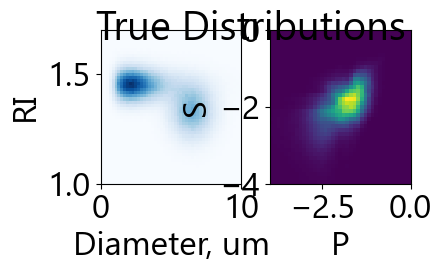

In [ ]:
## -----------------------------------------------------------------------------
## Generate True Distribution

num_samps = 1_000_000

# dp_mean =
dp_true = np.random.lognormal(1, 0.5, num_samps)
# dp_true[:500_000] = np.abs(np.random.normal(7, 1, 500_000))
dp_true[:400_000] = np.abs(np.random.normal(6.5, 1, 400_000))
ri_true = np.abs(np.random.normal(1.45, 0.05, num_samps))
ri_true[:400_000] = np.abs(np.random.normal(1.33, 0.08, 400_000))
X_true = np.column_stack((dp_true, ri_true))
U_meas = measure(X_true)
fy_meas = np.histogramdd(U_meas, bins=U_bin_edges)[0].ravel() / num_samps

fig, ax = plt.subplots(1, 2, figsize=(4, 2))
ax[0].hist2d(dp_true, ri_true, bins=X_bin_edges, cmap="Blues")
ax[1].hist2d(U_meas[:, 0], U_meas[:, 1], bins=U_bin_edges, cmap="viridis")
ax[0].set(xlabel="Diameter, um", ylabel="RI")
ax[1].set(xlabel="P", ylabel="S")
fig.suptitle("True Distributions")
fig.tight_layout()

In [ ]:
lapl = scipy.sparse.linalg.LaplacianNd(
    X_num_bins,
).tosparse()
a = cp.Variable(B.shape[1])
fx_reconstruct = (B @ a).reshape(X_num_bins, order="C")

eps = 1 / num_samps
# data_misfit = cp.sum_squares(fy_meas - K @ a) / len(fy_meas)
data_misfit = cp.sum(
    cp.rel_entr(K @ a + eps, fy_meas + eps) + cp.rel_entr(fy_meas + eps, K @ a + eps)
)

# Regularization Parameters
# lapl_weight = 1e-4
lapl_weight = cp.Parameter(nonneg=True)
fx_reconstr = (B @ a).reshape(X_num_bins, order="C")
# lapl_term = cp.sum_squares(cp.diff(fx_reconstr, 2, axis=0)) + cp.sum_squares(
#     cp.diff(fx_reconstr, 2, axis=1)
# )
lapl_term = cp.sum_squares(lapl @ B @ a)

objective = cp.Minimize(data_misfit + lapl_weight * lapl_term)
constraints = [0 <= B @ a, a.sum() == 1]
prob = cp.Problem(objective, constraints)

# weight_vals = np.logspace(0, 2, 25)
weight_vals = [
    17.78,
]
misfit_vals = np.zeros(len(weight_vals))
lapl_vals = np.zeros(len(weight_vals))
a_vals = np.zeros([len(weight_vals), k])
for i, weight_val in tqdm(enumerate(weight_vals)):
    lapl_weight.value = weight_val
    prob.solve(verbose=False, solver="mosek")
    misfit_vals[i] = data_misfit.value
    lapl_vals[i] = lapl_term.value
    a_vals[i, :] = a.value

1it [00:01,  1.12s/it]


[Text(0, 0.5, 'Solution Roughness'), Text(0.5, 0, 'Data Misfit')]

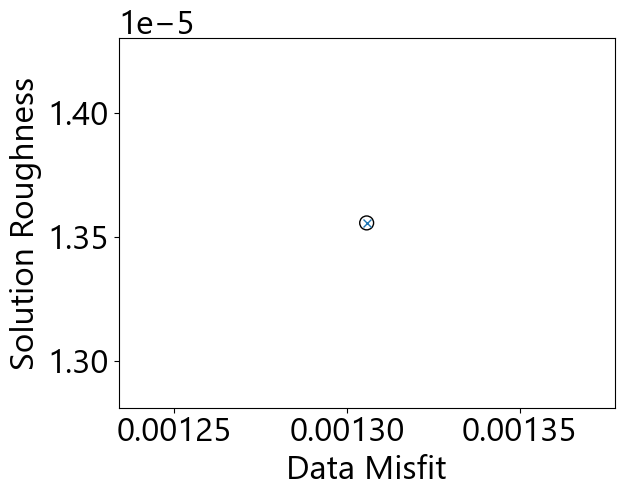

In [ ]:
ind = 0


fig, ax = plt.subplots()
# for i in range(len(weight_vals)):
ax.plot(misfit_vals, lapl_vals, marker="x")

# grad = np.gradient(lapl_vals, misfit_vals)
# curvature = np.gradient(grad, misfit_vals)
# max_curve_ind = np.argmax(curvature)
ax.scatter(
    misfit_vals[ind],
    lapl_vals[ind],
    marker="o",
    s=100,
    color="k",
    facecolors="none",
)

# ax.legend()
ax.set(ylabel="Solution Roughness", xlabel="Data Misfit")

C:\Users\kchoislattery3\AppData\Local\Temp\ipykernel_42844\1723694168.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
C:\Users\kchoislattery3\AppData\Local\Temp\ipykernel_42844\1723694168.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


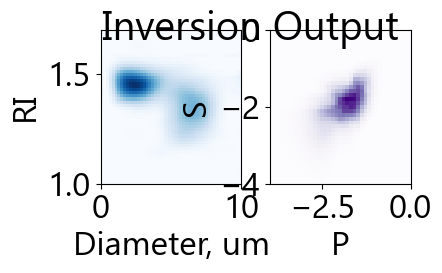

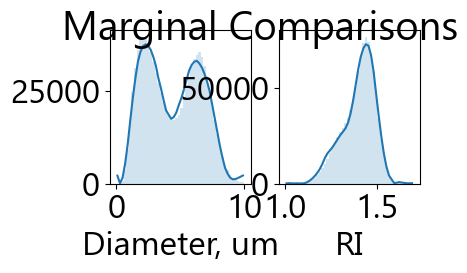

In [ ]:
# ind = 0
a_best = a_vals[ind, :]

# Plot inversion result
fig, ax = plt.subplots(1, 2, figsize=(4, 2))
ax[0].pcolormesh(
    X_bin_edges[0],
    X_bin_edges[1],
    (B @ a_best).reshape(X_num_bins).T,
    cmap="Blues",
)
ax[1].pcolormesh(
    U_bin_edges[0],
    U_bin_edges[1],
    (K @ a_best).reshape(U_num_bins).T,
    cmap="Purples",
)
ax[0].set(xlabel="Diameter, um", ylabel="RI")
ax[1].set(xlabel="P", ylabel="S")
fig.suptitle("Inversion Output")
fig.tight_layout()

fig, ax = plt.subplots(1, 2, figsize=(4, 2))

ax[0].plot(
    0.5 * (X_bin_edges[0][:-1] + X_bin_edges[0][1:]),
    (B @ a_best).reshape(X_num_bins).sum(axis=1) * num_samps,
)
ax[0].hist(dp_true, bins=X_bin_edges[0], color="C0", alpha=0.2)
ax[1].plot(
    0.5 * (X_bin_edges[1][:-1] + X_bin_edges[1][1:]),
    (B @ a_best).reshape(X_num_bins).sum(axis=0) * num_samps,
)
ax[0].set(xlabel="Diameter, um")
ax[1].set(xlabel="RI")
ax[1].hist(ri_true, bins=X_bin_edges[1], color="C0", alpha=0.2)
fig.suptitle("Marginal Comparisons")
fig.tight_layout()

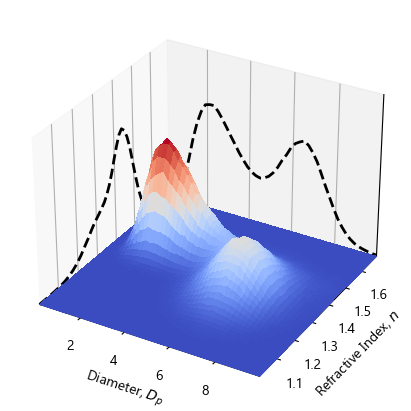

In [ ]:
def plot_surf_marginals(x, y, Z, ax, marginal_kw, only_marginals=False, label=None):
    X, Y = np.meshgrid(x, y)

    px = np.trapezoid(Z, y, axis=0)
    py = np.trapezoid(Z, x, axis=1)

    px = px * (Z.max() / px.max())
    py = py * (Z.max() / py.max())

    # fig = plt.figure(figsize=(6, 6))
    # ax = fig.add_subplot(projection="3d")

    # Main surface
    # ax.plot_surface(X, Y, Z, cmap="coolwarm", alpha=0.9)
    if not only_marginals:
        ax.plot_surface(
            X, Y, Z, cmap="coolwarm", alpha=1, linewidth=0, antialiased=False
        )
    # ax.contour(X, Y, Z, offset=0)

    # Set consistent limits
    ax.set_xlim(X.min(), X.max())
    ax.set_ylim(Y.min(), Y.max())
    ax.set_zlim(0, 1.5 * Z.max())

    # ---- Project p_x(x) onto Y = min wall ----
    ax.plot(x, np.full_like(x, y.max()), px, **marginal_kw, linewidth=2, label=label)

    # ---- Project p_y(y) onto X = max wall ----
    ax.plot(np.full_like(y, x.min()), y, py, **marginal_kw, linewidth=2)


H_true = np.histogramdd(X_true, bins=X_bin_edges)[0]
plt.rcParams.update({"font.size": 10})

fig = plt.figure(figsize=[4,4], constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")
# fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
plot_surf_marginals(
    edges2centers(X_bin_edges[0]),
    edges2centers(X_bin_edges[1]),
    H_true.T,
    ax,
    marginal_kw={"color": "k", "linestyle": "--"},
)
ax.set(zticks=[], xlabel="Diameter, $D_p$", ylabel="Refractive Index, $n$")
fig.canvas.draw() 
# fig.savefig("forwardscat_true.pdf", transparent=True)
# fig.tight_layout()

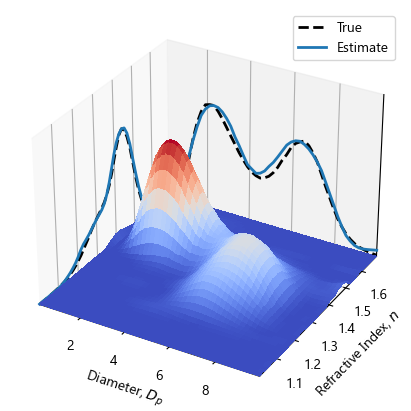

In [ ]:
plt.rcParams.update({"font.size": 10})
H_est = (B @ a_best).reshape(X_num_bins)

fig = plt.figure(figsize=[4,4], constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")
plot_surf_marginals(
    edges2centers(X_bin_edges[0]),
    edges2centers(X_bin_edges[1]),
    H_true.T * (H_est.max() / H_true.max()),
    ax,
    only_marginals=True,
    marginal_kw={"color": "k", "linestyle": "--"},
    label="True",
)
plot_surf_marginals(
    edges2centers(X_bin_edges[0]),
    edges2centers(X_bin_edges[1]),
    H_est.T,
    ax,
    marginal_kw={"color": "C0"},
    label="Estimate",
)
ax.set(zticks=[], xlabel="Diameter, $D_p$", ylabel="Refractive Index, $n$")
ax.legend()
# fig.tight_layout()
fig.savefig("backscat_nofilt_estimate.pdf", transparent=True)

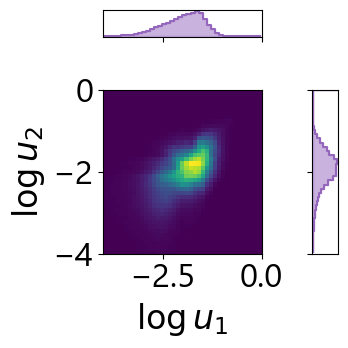

In [ ]:
plt.rcParams.update({"font.size": 24})

Hu_meas = np.histogramdd(U_meas, bins=U_bin_edges)[0]

fig, ax = plt.subplots(
    2,
    2,
    figsize=[4, 4],
    gridspec_kw={"width_ratios": [6, 1], "height_ratios": [1, 6]},
    sharex="col",
    sharey="row",
)

ax[0, 1].set(visible=False)
ax[1, 0].pcolormesh(U_bin_edges[0], U_bin_edges[1], Hu_meas.T)
ax[1, 0].set(xlabel="$\\log u_1$", ylabel="$\\log u_2$")
ax[0, 0].step(edges2centers(U_bin_edges[0]), Hu_meas.sum(axis=1), color="C4")
ax[0, 0].set(yticks=[])
ax[0, 0].fill_between(
    edges2centers(U_bin_edges[0]),
    Hu_meas.sum(axis=1),
    step="pre",
    alpha=0.5,
    color="C4",
)
ax[1, 1].set(xticks=[])
ax[1, 1].step(Hu_meas.sum(axis=0), edges2centers(U_bin_edges[1]), color="C4")
ax[1, 1].fill_between(
    Hu_meas.sum(axis=0),
    edges2centers(U_bin_edges[1]),
    step="pre",
    alpha=0.5,
    color="C4",
)
fig.tight_layout()
fig.savefig("backscat_nofilt_measurements.pdf", transparent=True)